# BYU CS 473 — K-Nearest Neighbors

In this assignment, you will explore **KNN classification** using different distance metrics, understand the **curse of dimensionality**, and learn how KNN can be adapted for **open set recognition** and **out-of-distribution (OOD) detection**.

---

## Learning Goals
- Understand and compare different distance metrics in KNN
- Explore the effect of high-dimensional data (curse of dimensionality)
- Implement open set recognition with KNN
- Apply KNN for simple OOD detection


## 1. Loading the Iris Dataset

We begin with the Iris dataset.


In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### Exercise 1
Print the shapes of the training and test sets, and display the first 5 rows of `X_train`.


In [11]:
# Your code here
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

print(f'first 5 rows of X_train: ')
print(X_train[:5, :])

X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)
first 5 rows of X_train: 
[[-0.41600969 -1.51316008 -0.03296571 -0.26238682]
 [ 0.55333328 -0.59237301  0.76275827  0.3957741 ]
 [ 0.67450115  0.09821729  0.99010798  0.79067065]
 [ 0.91683689 -0.13197948  0.36489628  0.26414192]
 [ 1.64384411  1.24920112  1.33113254  1.71209594]]


## 2. KNN with Different Distance Metrics

KNN relies on a distance function to measure similarity. Common choices include:

- **Euclidean** (straight-line distance)  
- **Manhattan** (sum of absolute differences)  
- **Chebyshev** (max difference)  
- **Mahalanobis** (accounts for correlations between features)  


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
distances = ["euclidean", "manhattan", "chebyshev"]

for d in distances:
    knn = KNeighborsClassifier(n_neighbors=5, metric=d)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"Metric: {d}, Accuracy: {acc:.3f}")

#mahalanobis dist:
sigma = np.cov(X_train, rowvar=False)
sigma_inv = np.linalg.inv(sigma)
print(f'sigma = \n{sigma}')
print(f'sigma_inv = \n{sigma_inv}')

knn_mah = KNeighborsClassifier(n_neighbors=5,
                           metric='mahalanobis',
                           metric_params={'VI': sigma_inv})
knn_mah.fit(X_train, y_train)
preds_mah = knn.predict(X_test)
acc_mah=accuracy_score(y_test, preds_mah)
print(f"Metric: Mahalanobis , Accuracy: {acc_mah:.3f}")


Metric: euclidean, Accuracy: 1.000
Metric: manhattan, Accuracy: 1.000
Metric: chebyshev, Accuracy: 0.956
sigma = 
[[ 1.01948752 -0.03199203  0.85630849  0.78819025]
 [-0.03199203  0.92990653 -0.31955245 -0.25287159]
 [ 0.85630849 -0.31955245  0.95721522  0.91622003]
 [ 0.78819025 -0.25287159  0.91622003  0.95581747]]
sigma_inv = 
[[  6.90229176  -2.41010649 -11.16509249   4.37313078]
 [ -2.41010649   2.11122128   5.13936873  -2.38047776]
 [-11.16509249   5.13936873  31.93903873 -20.04919355]
 [  4.37313078  -2.38047776 -20.04919355  16.02885366]]
Metric: Mahalanobis , Accuracy: 0.956


### Exercise 2
Add **Mahalanobis distance** to the code above.  
Hint: compute the covariance matrix and pass it via `metric_params`.  

Which distance metric performed best? Why might that be the case?



We see that actually, euclidean and manhattan performed the best. Mahalanobis and chebyshev underperformed them slightly.

This is weird because I personally expected more fine-tuned MD to have more accurate distances.

It makes sense that chebyshev isn't as good, because it ignores all of the dimensions that aren't as big as the biggest, ebven though they could be very close.

After more careful inspection, we see that the cov matrix between features 3 and 3 would highly suppress their differences, but they are actually the most important features for determining class. So we don't weight them high enough.

## 3. Curse of Dimensionality

As the number of features increases, distances between points become less meaningful.  
We will test KNN on synthetic datasets with increasing dimensionality.


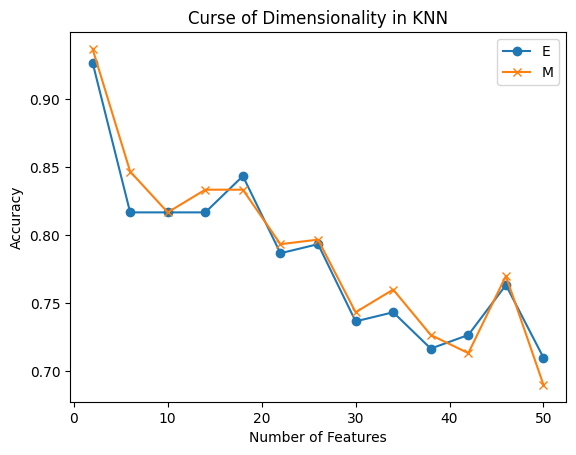

In [26]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

dims = range(2, 51, 4)
accuracies = []
maccuracies = []

for d in dims:
    X_high, y_high = make_classification(
        n_samples=1000,
        n_features=d,
        n_informative=2,
        n_redundant=0,
        n_repeated=0,
        random_state=42
    )
    X_tr, X_te, y_tr, y_te = train_test_split(X_high, y_high, test_size=0.3, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
    knn.fit(X_tr, y_tr)
    acc = knn.score(X_te, y_te)
    accuracies.append(acc)

    mknn = KNeighborsClassifier(n_neighbors=5, metric="manhattan")
    mknn.fit(X_tr, y_tr)
    macc = mknn.score(X_te, y_te)
    maccuracies.append(macc)

plt.plot(dims, accuracies, marker="o")
plt.plot(dims, maccuracies, marker="x")
plt.legend('EM')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Curse of Dimensionality in KNN")
plt.show()


### Exercise 3
Modify the code above to also test **Manhattan distance** and plot both curves together.

What happens to accuracy as dimensionality increases? Why?

Accuracy is a nearly- monotonic-decreasing function

This is because the more dimensions we have, the higher chance we have of every point being far away in at least 1 dimension. Because of this, all of the datapoints just look far.

## 4. Open Set Recognition

KNN assumes all test samples belong to known classes. But in practice, a test point may not belong to any training class.

We simulate this by generating a synthetic "unknown" dataset.


In [28]:
import numpy as np

from sklearn.datasets import make_classification

# Synthetic unknown samples
X_unknown, y_unknown = make_classification(n_samples=200, n_features=4, n_classes=1, random_state=99)

knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, y_train)

unknown_preds = knn.predict(X_unknown)
print("Unique predictions for unknown samples:", np.unique(unknown_preds))

Unique predictions for unknown samples: [0 1 2]


In [37]:
distances, indices = knn.kneighbors(X_unknown, n_neighbors =1)

distances = distances.flatten()

threshold = 1
# print(dir(knn))
open_set_preds = unknown_preds.copy()

open_set_preds[distances>threshold] = -1

print("unique preudctions after thresholding:", np.unique(open_set_preds))
print(f'number of samples correctly flagged as "unknown" (-1): {np.sum(open_set_preds == -1)}')

unique preudctions after thresholding: [-1  0  1  2]
number of samples correctly flagged as "unknown" (-1): 96


### Exercise 4
Modify the code to compute the distance to the nearest neighbor for each unknown sample.  
If the distance is above a threshold, classify it as **unknown**.

How does thresholding improve open set recognition?

It is better to say we don't know the class of something and maintain smaller decision boundaries than to have infinitely wide decision boundaries just to say we know something. So having a threshold gives us a much-needed confidence interval of sorts.

## 5. Out-of-Distribution (OOD) Detection

OOD detection identifies samples that do not belong to the same distribution as the training data.


Average distance (in-distribution): 0.31853062619139316
Average distance (OOD): 1.2213708916568842


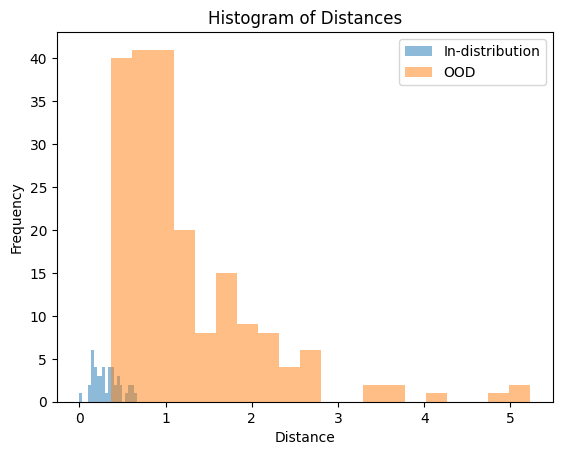

In [45]:
from sklearn.metrics import pairwise_distances

in_dist = pairwise_distances(X_test, X_train).min(axis=1)
out_dist = pairwise_distances(X_unknown, X_train).min(axis=1)

print("Average distance (in-distribution):", np.mean(in_dist))
print("Average distance (OOD):", np.mean(out_dist))

plt.hist(in_dist, bins=20, alpha=0.5, label="In-distribution")
plt.hist(out_dist, bins=20, alpha=0.5, label="OOD")
plt.legend()
plt.title("Histogram of Distances")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

## Exersise 5
Plot histograms of `in_dist` and `out_dist` on the same figure.  
What do you observe?
Suggest a thresholding rule to separate in-distribution from OOD samples.

We have pretty distinct clustering for in-distribution, and out-of-distribution is much wider and skewed.

I see that at approximately distance = .4, we get the fist OOD observations. We therefore, we could use a threshold of about 0.4 to separate the two, being careful, and a threshold of .7 being aggressive. It depends on our goals for OOD classification.

## 6. Reflection

1. Which distance metric was most robust?  
2. How did dimensionality affect KNN performance?  
3. Why is open set recognition important?  
4. How might KNN be adapted for stronger OOD detection?  


1. The most robust distance metric, I would argue should theoretically be mahalanobis distance, but the most accurate one for these purposeses were euclidean and manhatten.

2.
Dimensionality almost always decreases KNN performance because distnace itself becomes "polluted" when there are so many dimensions that at least one of them is bound to be big. Perhaps there are methods that use the median distance among dimensions, though that would bring up its own issues.

3.
Open set recognition allows us to do away with trying to classify datapoints that we have no business classifying. It admits some epistemic uncertainty and lets us more robustly evaluate the validity of the model. This is important because in the real world, our data usually isn't so perfect.

4.
KNN's main problems that I saw in the lab for OOD detection stem from distance. The distances stop mattering in high dimensions and mahalanobis distance also doesn't help in this scenario. I think that using FLDA to cut down on dimensions and maximize class separation would make it easier for OOD detection. Other methods could also be the averaeg K-distance instead of looking at the 1st nearest neighbor, and having different thresholds per class. We could do this with the class-specific variance. This makes a lot of sense because tightly distributed classes don't have the same true p density as loosely clustered classes!